# Univariate EDA

Univariate EDA examines each variable in isolation — understanding its distribution, central tendency, spread, and anomalies before involving any other variable.

This is always the first pass after data cleaning: build a mental model of every column before looking at relationships.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

df = sns.load_dataset('titanic')
print('Shape:', df.shape)
df.head()

Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Numerical Variables

For a numerical variable, univariate EDA answers:
- Where is the centre? (mean, median)
- How spread out is it? (std, IQR)
- Is it symmetric or skewed?
- Are there outliers?

**Three-panel profile**: Histogram + KDE | Boxplot | Q-Q plot

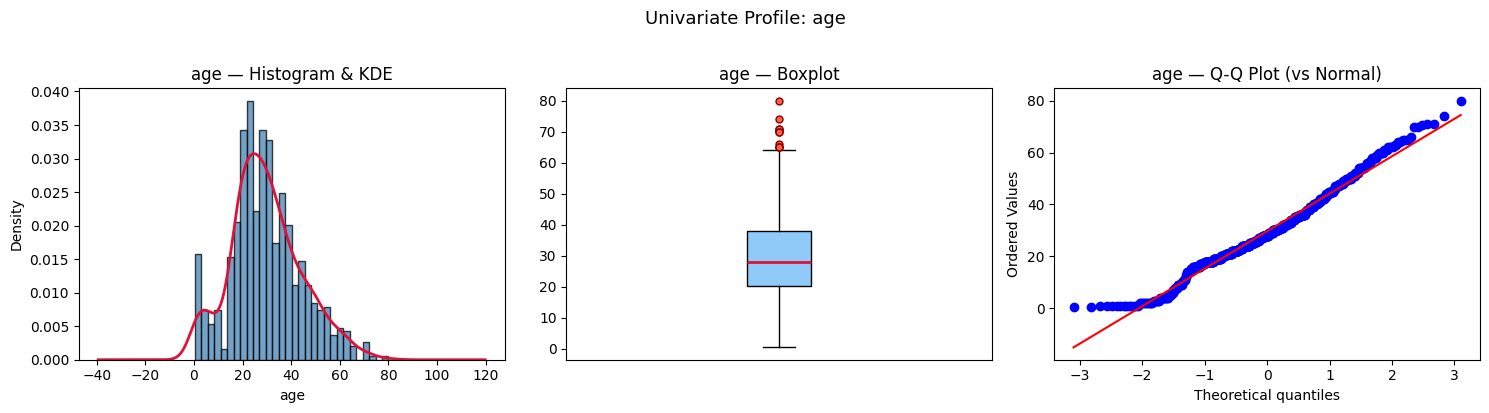

  Statistic          Value
  ────────────────────────────
  count              714.0000
  mean               29.6991
  std                14.5265
  min                0.4200
  25%                20.1250
  50%                28.0000
  75%                38.0000
  max                80.0000
  skewness           0.3891
  kurtosis           0.1783
  missing            177 (19.9%)


In [2]:
def univariate_numerical(series):
    """Three-panel univariate profile for a numerical column."""
    name = series.name
    s = series.dropna()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Histogram + KDE overlay
    axes[0].hist(s, bins=30, color='steelblue', edgecolor='black', alpha=0.75, density=True)
    s.plot.kde(ax=axes[0], color='crimson', linewidth=2)
    axes[0].set_title(f'{name} — Histogram & KDE')
    axes[0].set_xlabel(name)
    axes[0].set_ylabel('Density')

    # Boxplot
    axes[1].boxplot(s, patch_artist=True,
                    boxprops=dict(facecolor='#90CAF9'),
                    medianprops=dict(color='crimson', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='tomato',
                                   markeredgecolor='darkred', markersize=5))
    axes[1].set_title(f'{name} — Boxplot')
    axes[1].set_xticks([])

    # Q-Q plot (proximity to diagonal = proximity to normal)
    stats.probplot(s, dist='norm', plot=axes[2])
    axes[2].set_title(f'{name} — Q-Q Plot (vs Normal)')

    plt.suptitle(f'Univariate Profile: {name}', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    # Summary stats
    desc = s.describe(percentiles=[0.25, 0.5, 0.75])
    print(f"  {'Statistic':<18} Value")
    print('  ' + '─' * 28)
    for k, v in desc.items():
        print(f"  {k:<18} {v:.4f}")
    print(f"  {'skewness':<18} {s.skew():.4f}")
    print(f"  {'kurtosis':<18} {s.kurtosis():.4f}")
    print(f"  {'missing':<18} {series.isna().sum()} ({series.isna().mean()*100:.1f}%)")

univariate_numerical(df['age'])

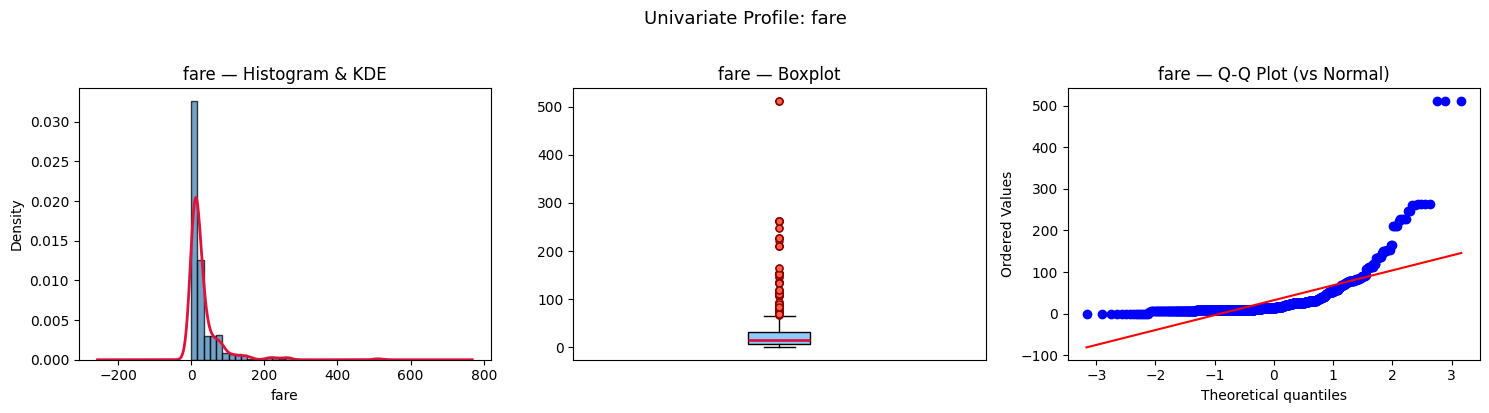

  Statistic          Value
  ────────────────────────────
  count              891.0000
  mean               32.2042
  std                49.6934
  min                0.0000
  25%                7.9104
  50%                14.4542
  75%                31.0000
  max                512.3292
  skewness           4.7873
  kurtosis           33.3981
  missing            0 (0.0%)


In [3]:
univariate_numerical(df['fare'])

### Reading the three panels

| Panel | What to look for |
|---|---|
| **Histogram + KDE** | Shape: symmetric, right-skewed, left-skewed, bimodal |
| **Boxplot** | Median (red), IQR (box height), whisker length, outlier dots |
| **Q-Q plot** | Points on diagonal = normal; S-curve = skewed; heavy tails = fat ends |

| Skewness value | Interpretation |
|---|---|
| 0 | Symmetric |
| > 1 | Strongly right-skewed (long right tail) |
| < −1 | Strongly left-skewed (long left tail) |

## Categorical Variables

For a categorical variable, univariate EDA answers:
- How many distinct categories?
- What is the frequency of each?
- Is the distribution balanced or dominated by one category (class imbalance)?

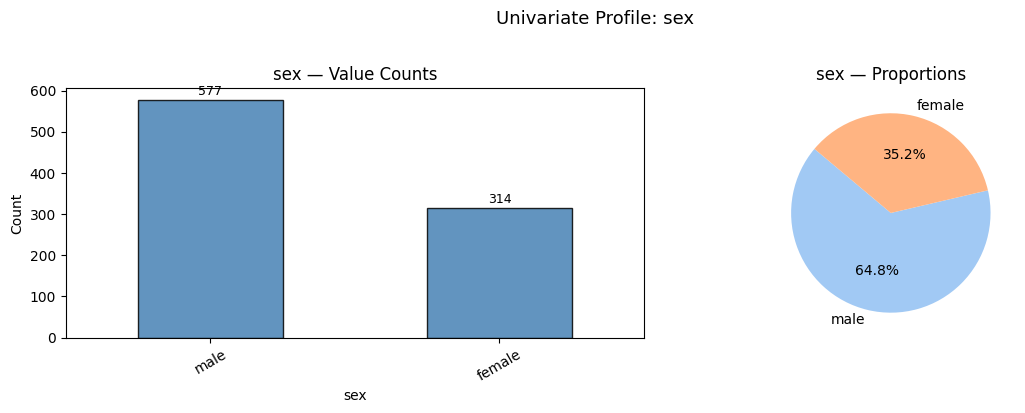

  Unique categories : 2
  Missing values    : 0 (0.0%)

        count  pct (%)
sex                   
male      577     64.8
female    314     35.2


In [4]:
def univariate_categorical(series, top_n=10):
    """Bar chart + pie/proportion chart for a categorical column."""
    name = series.name
    counts = series.value_counts().head(top_n)
    pcts = (counts / len(series) * 100).round(1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Bar chart with count labels
    counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black', alpha=0.85)
    axes[0].set_title(f'{name} — Value Counts')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=30)
    for i, v in enumerate(counts):
        axes[0].text(i, v + max(counts) * 0.01, str(v),
                     ha='center', va='bottom', fontsize=9)

    # Pie chart (≤ 6 categories) or horizontal proportion bar
    n_cats = len(counts)
    if n_cats <= 6:
        axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%',
                    startangle=140,
                    colors=sns.color_palette('pastel', n_cats))
        axes[1].set_title(f'{name} — Proportions')
    else:
        pcts.plot(kind='barh', ax=axes[1], color='coral', edgecolor='black', alpha=0.85)
        axes[1].set_title(f'{name} — Proportion (%)')
        axes[1].set_xlabel('Percent (%)')

    plt.suptitle(f'Univariate Profile: {name}', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"  Unique categories : {series.nunique()}")
    print(f"  Missing values    : {series.isna().sum()} ({series.isna().mean()*100:.1f}%)")
    print()
    print(pd.DataFrame({'count': counts, 'pct (%)': pcts}).to_string())

univariate_categorical(df['sex'])

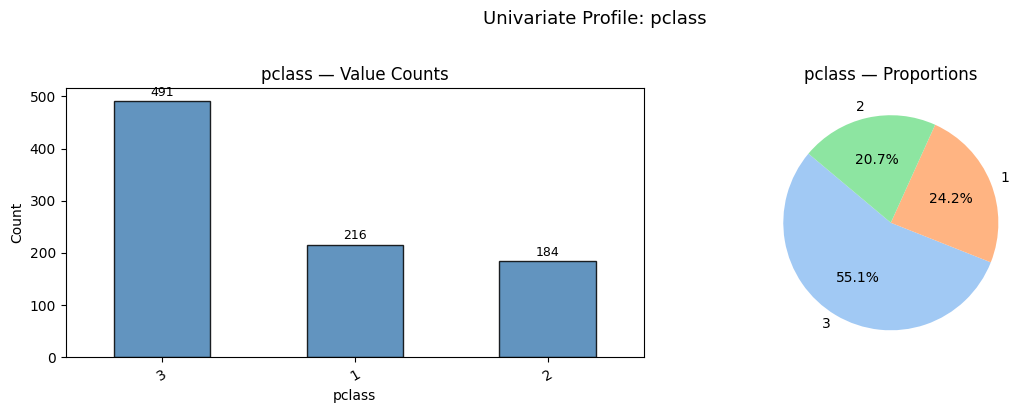

  Unique categories : 3
  Missing values    : 0 (0.0%)

        count  pct (%)
pclass                
3         491     55.1
1         216     24.2
2         184     20.7


In [5]:
univariate_categorical(df['pclass'])

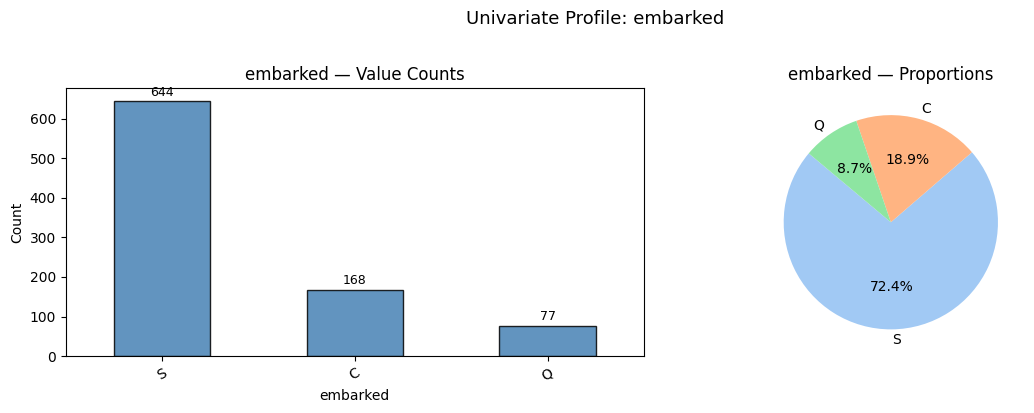

  Unique categories : 3
  Missing values    : 2 (0.2%)

          count  pct (%)
embarked                
S           644     72.3
C           168     18.9
Q            77      8.6


In [6]:
univariate_categorical(df['embarked'])

## Automated Sweep — All Columns

Apply univariate profiling to every column with one function call. Useful at the start of any new project.

NUMERICAL COLUMNS  (2 total)

── age 


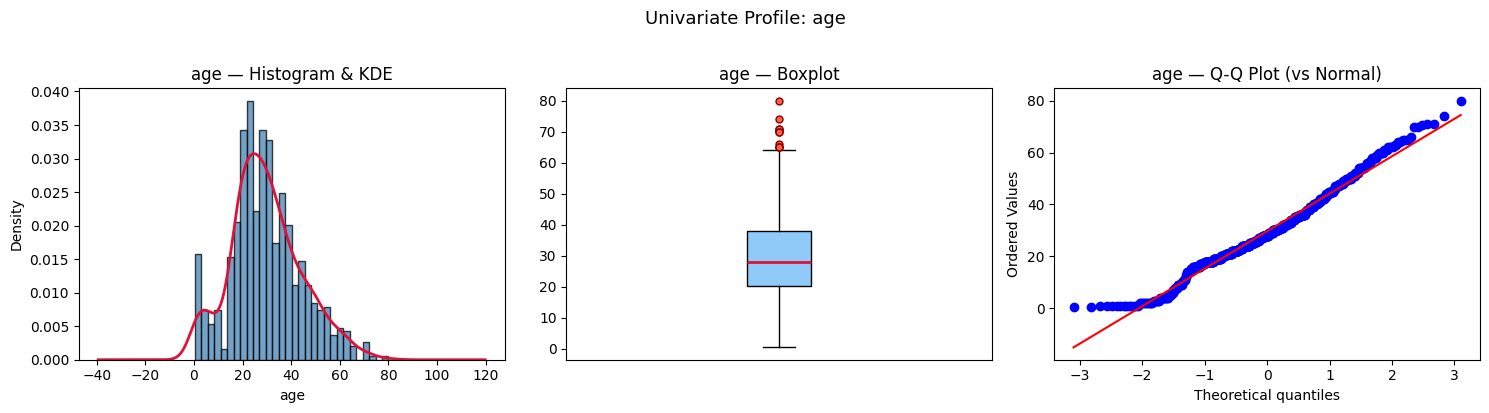

  Statistic          Value
  ────────────────────────────
  count              714.0000
  mean               29.6991
  std                14.5265
  min                0.4200
  25%                20.1250
  50%                28.0000
  75%                38.0000
  max                80.0000
  skewness           0.3891
  kurtosis           0.1783
  missing            177 (19.9%)


── fare 


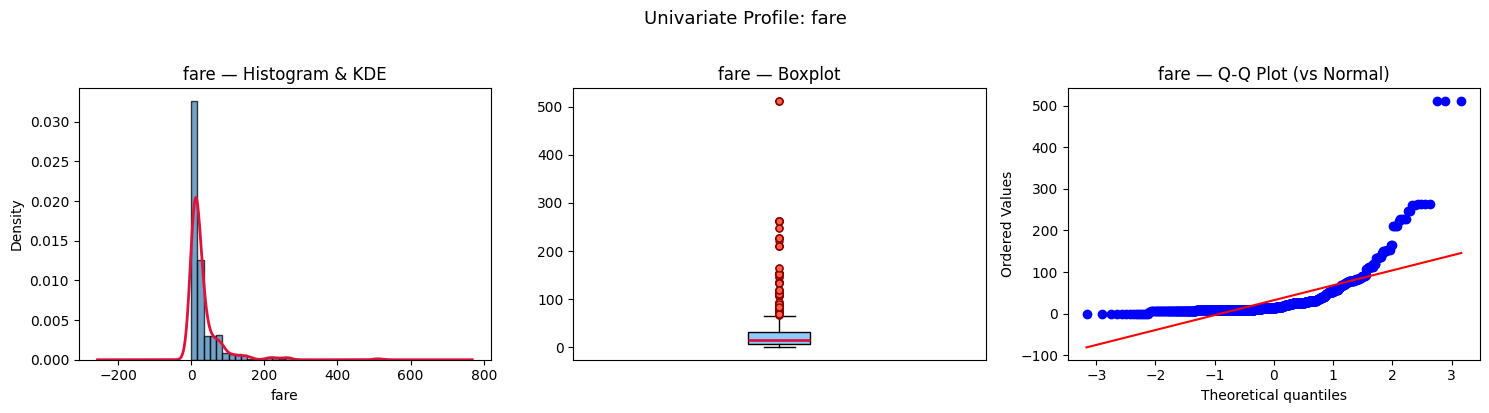

  Statistic          Value
  ────────────────────────────
  count              891.0000
  mean               32.2042
  std                49.6934
  min                0.0000
  25%                7.9104
  50%                14.4542
  75%                31.0000
  max                512.3292
  skewness           4.7873
  kurtosis           33.3981
  missing            0 (0.0%)

CATEGORICAL COLUMNS  (2 total)

── sex 


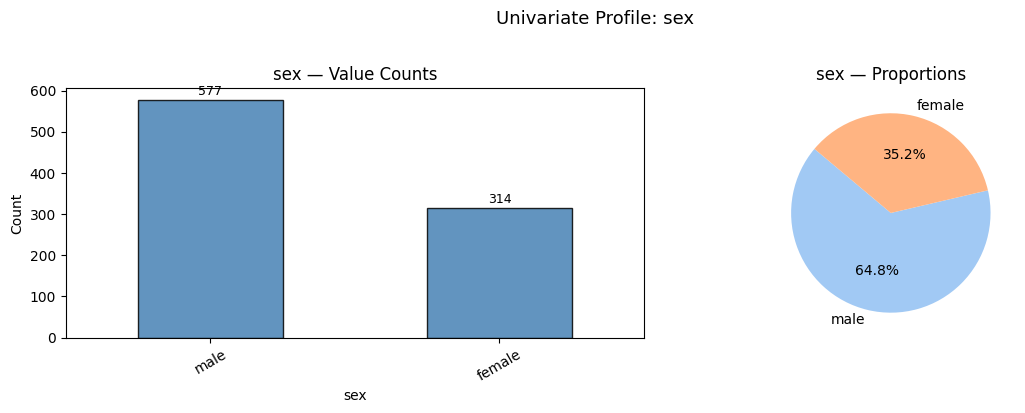

  Unique categories : 2
  Missing values    : 0 (0.0%)

        count  pct (%)
sex                   
male      577     64.8
female    314     35.2


── survived 


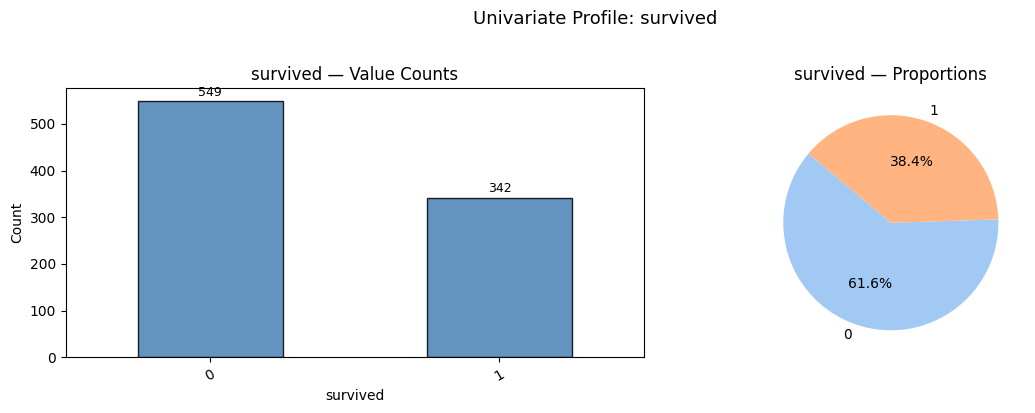

  Unique categories : 2
  Missing values    : 0 (0.0%)

          count  pct (%)
survived                
0           549     61.6
1           342     38.4



In [7]:
def univariate_sweep(df, num_cols=None, cat_cols=None):
    """Run univariate profiling for all numerical and categorical columns."""
    num_cols = num_cols or df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    cat_cols = cat_cols or df.select_dtypes(
        include=['object', 'category', 'bool']).columns.tolist()

    print('=' * 60)
    print(f'NUMERICAL COLUMNS  ({len(num_cols)} total)')
    print('=' * 60)
    for col in num_cols:
        print(f'\n── {col} ')
        univariate_numerical(df[col])
        print()

    print('=' * 60)
    print(f'CATEGORICAL COLUMNS  ({len(cat_cols)} total)')
    print('=' * 60)
    for col in cat_cols:
        print(f'\n── {col} ')
        univariate_categorical(df[col])
        print()

# Demo on a focused subset
univariate_sweep(df, num_cols=['age', 'fare'], cat_cols=['sex', 'survived'])

## Key Takeaways

| Variable type | Primary plots | Key statistics |
|---|---|---|
| Numerical | Histogram, KDE, Boxplot, Q-Q | mean, median, std, skewness, kurtosis |
| Categorical | Bar chart, Pie chart | count, proportion, cardinality |

**Checklist per variable:**
- Missing values and their proportion
- Distribution shape (symmetric, skewed, bimodal)
- Outliers (boxplot whiskers and dots)
- Dominant or rare categories — signals class imbalance

---
## EDA Assumptions & Diagnostics

Before any statistical model is valid, the underlying data must satisfy four assumptions:

| Assumption | What it means | Plot to check |
|---|---|---|
| **Randomness** | Observations are independent — no autocorrelation | Lag plot |
| **Fixed location** | Mean is stable over time / run order | Run sequence plot |
| **Fixed variation** | Variance is stable over time / run order | Run sequence plot |
| **Fixed distribution** | Values come from the same distribution | Histogram + Q-Q plot |

These are not assumptions about the *model* — they are assumptions about the *data-generating process*. If any of them fail, every downstream statistic (mean, std, confidence intervals) becomes unreliable.

The All four assumptions can be tested simultaneously with a single combined view called the **4-Plot**.

### Run Sequence Plot

Plot observations in the order they were collected (Y_i vs i). Reveals:
- **Drift**: mean is slowly increasing or decreasing → fixed location violated
- **Shifts**: sudden jump in values → data collection changed
- **Heteroscedasticity**: spread grows or shrinks over time → fixed variation violated
- **Stable process**: flat, constant-bandwidth band → location and variation are fixed

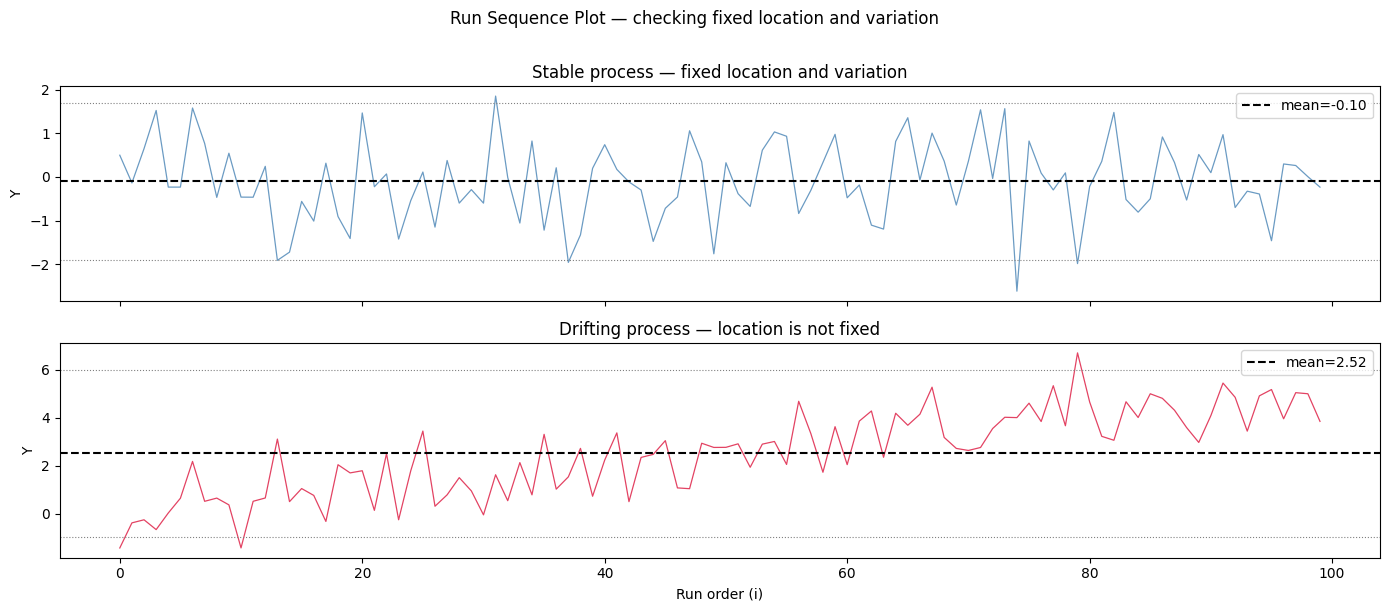

Interpretation:
  Flat, equi-banded band → location and variation are fixed (assumption holds)
  Trending line           → location is drifting (assumption violated)


In [8]:
import numpy as np

# Simulate two contrasting processes
np.random.seed(42)
n = 100

# Stable process: fixed location and variation
y_stable = np.random.normal(loc=0, scale=1, size=n)

# Drifting process: mean increases over time
y_drift = np.random.normal(loc=np.linspace(0, 5, n), scale=1, size=n)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

for ax, y, title, color in zip(
    axes,
    [y_stable, y_drift],
    ['Stable process — fixed location and variation', 'Drifting process — location is not fixed'],
    ['steelblue', 'crimson']
):
    ax.plot(y, color=color, linewidth=0.9, alpha=0.8)
    ax.axhline(y.mean(), color='black', linewidth=1.5, linestyle='--', label=f'mean={y.mean():.2f}')
    ax.axhline(y.mean() + 2*y.std(), color='gray', linewidth=0.8, linestyle=':')
    ax.axhline(y.mean() - 2*y.std(), color='gray', linewidth=0.8, linestyle=':')
    ax.set_title(title)
    ax.set_ylabel('Y')
    ax.legend(loc='upper right')

axes[1].set_xlabel('Run order (i)')
plt.suptitle('Run Sequence Plot — checking fixed location and variation', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print("Interpretation:")
print("  Flat, equi-banded band → location and variation are fixed (assumption holds)")
print("  Trending line           → location is drifting (assumption violated)")

### Lag Plot

Plot Y_i on the y-axis vs Y_{i-1} (the previous observation) on the x-axis. Checks whether consecutive observations are **independent**.

| Pattern | What it means |
|---|---|
| Structureless cloud | Random — observations are independent ✓ |
| Diagonal line (positive) | Positive autocorrelation — each value predicts the next |
| Diagonal line (negative) | Negative autocorrelation — alternating high/low pattern |
| Ellipse or curve | Non-linear dependence |

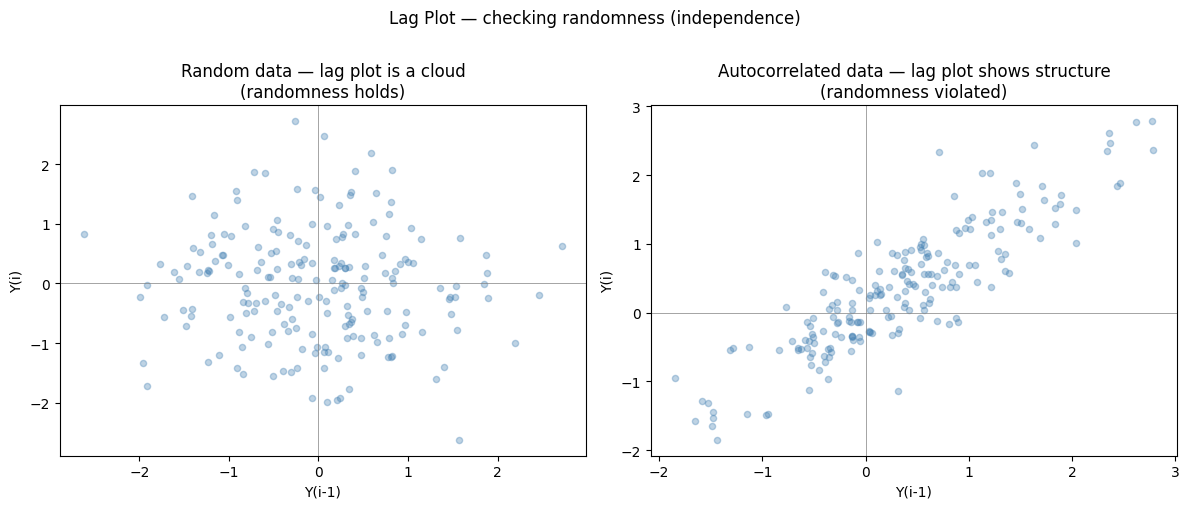

In [9]:
np.random.seed(42)
n = 200

# Random (independent)
y_random = np.random.normal(0, 1, n)

# Autocorrelated (AR(1): each value = 0.9 * previous + noise)
y_ar = np.zeros(n)
y_ar[0] = np.random.normal(0, 1)
for i in range(1, n):
    y_ar[i] = 0.9 * y_ar[i-1] + np.random.normal(0, 0.44)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y, title in zip(
    axes,
    [y_random, y_ar],
    ['Random data — lag plot is a cloud\n(randomness holds)',
     'Autocorrelated data — lag plot shows structure\n(randomness violated)']
):
    ax.scatter(y[:-1], y[1:], alpha=0.35, s=20, color='steelblue')
    ax.set_xlabel('Y(i-1)')
    ax.set_ylabel('Y(i)')
    ax.set_title(title)
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)

plt.suptitle('Lag Plot — checking randomness (independence)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

### The 4-Plot — Complete Assumption Diagnostic

The 4-Plot combines all four assumption checks into a single 2×2 figure:

| Position | Plot | Tests |
|---|---|---|
| Upper-left | Run sequence plot | Fixed location, fixed variation |
| Upper-right | Lag plot | Randomness (independence) |
| Lower-left | Histogram | Fixed distribution (bell shape?) |
| Lower-right | Normal probability plot | Fixed distribution (linear?) |

A process is said to be "in statistical control" when all four assumptions hold simultaneously.

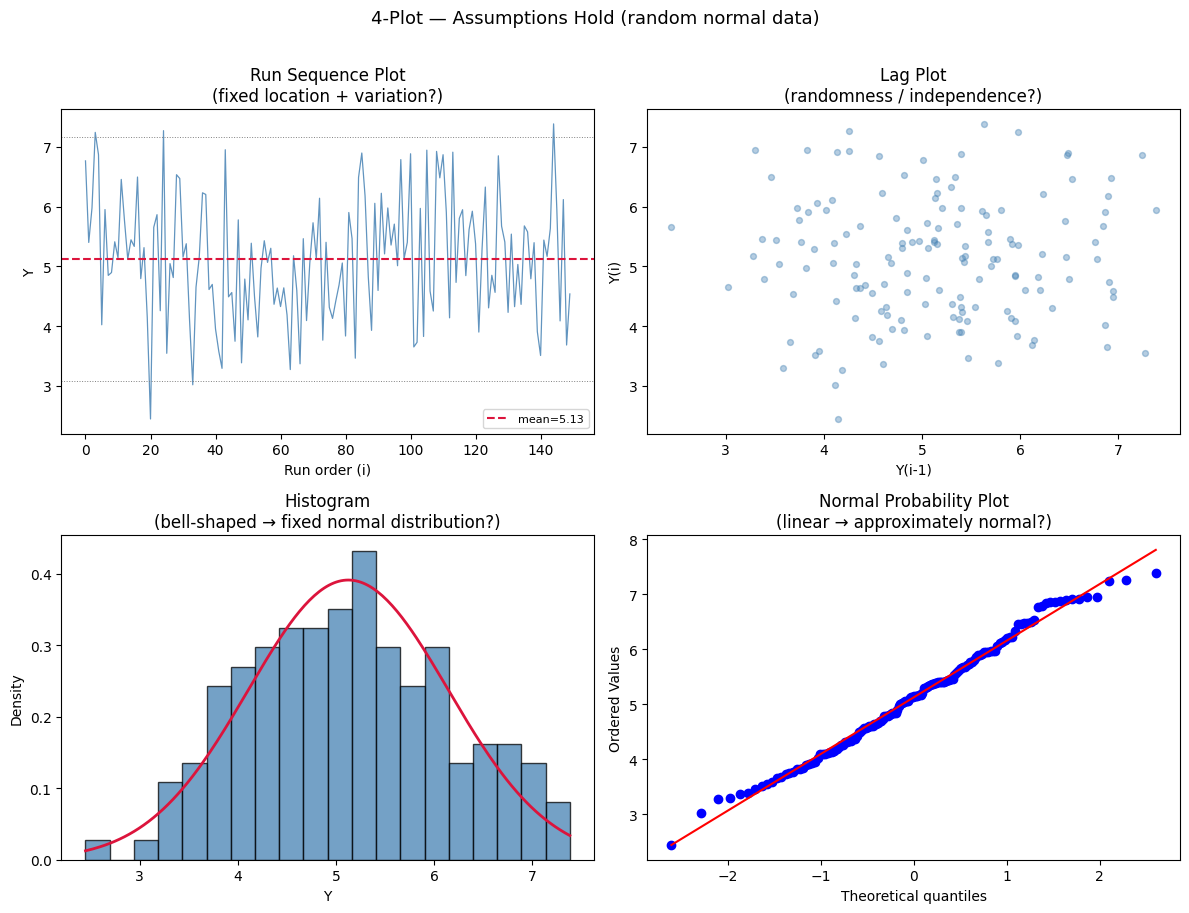

In [10]:
from scipy import stats as scipy_stats

def four_plot(y, title='4-Plot'):
    """
    4-Plot: run sequence, lag plot, histogram, normal probability plot.
    Tests the four underlying assumptions: fixed location, fixed variation,
    randomness, and fixed distribution.
    """
    y = np.asarray(y)
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    fig.suptitle(title, fontsize=13, y=1.01)

    # Upper-left: run sequence plot
    ax = axes[0, 0]
    ax.plot(y, color='steelblue', linewidth=0.9, alpha=0.85)
    ax.axhline(y.mean(), color='crimson', linewidth=1.5, linestyle='--', label=f'mean={y.mean():.2f}')
    ax.axhline(y.mean() + 2*y.std(), color='gray', linewidth=0.7, linestyle=':')
    ax.axhline(y.mean() - 2*y.std(), color='gray', linewidth=0.7, linestyle=':')
    ax.set_title('Run Sequence Plot\n(fixed location + variation?)')
    ax.set_xlabel('Run order (i)')
    ax.set_ylabel('Y')
    ax.legend(fontsize=8)

    # Upper-right: lag plot
    ax = axes[0, 1]
    ax.scatter(y[:-1], y[1:], alpha=0.4, s=18, color='steelblue')
    ax.set_title('Lag Plot\n(randomness / independence?)')
    ax.set_xlabel('Y(i-1)')
    ax.set_ylabel('Y(i)')

    # Lower-left: histogram
    ax = axes[1, 0]
    ax.hist(y, bins=20, color='steelblue', edgecolor='black', alpha=0.75, density=True)
    xr = np.linspace(y.min(), y.max(), 200)
    ax.plot(xr, scipy_stats.norm.pdf(xr, y.mean(), y.std()), 'crimson', linewidth=2)
    ax.set_title('Histogram\n(bell-shaped → fixed normal distribution?)')
    ax.set_xlabel('Y')
    ax.set_ylabel('Density')

    # Lower-right: normal probability plot
    ax = axes[1, 1]
    scipy_stats.probplot(y, dist='norm', plot=ax)
    ax.set_title('Normal Probability Plot\n(linear → approximately normal?)')

    plt.tight_layout()
    plt.show()


# Demo 1: well-behaved data — all assumptions hold
np.random.seed(0)
y_good = np.random.normal(loc=5, scale=1, size=150)
four_plot(y_good, title='4-Plot — Assumptions Hold (random normal data)')

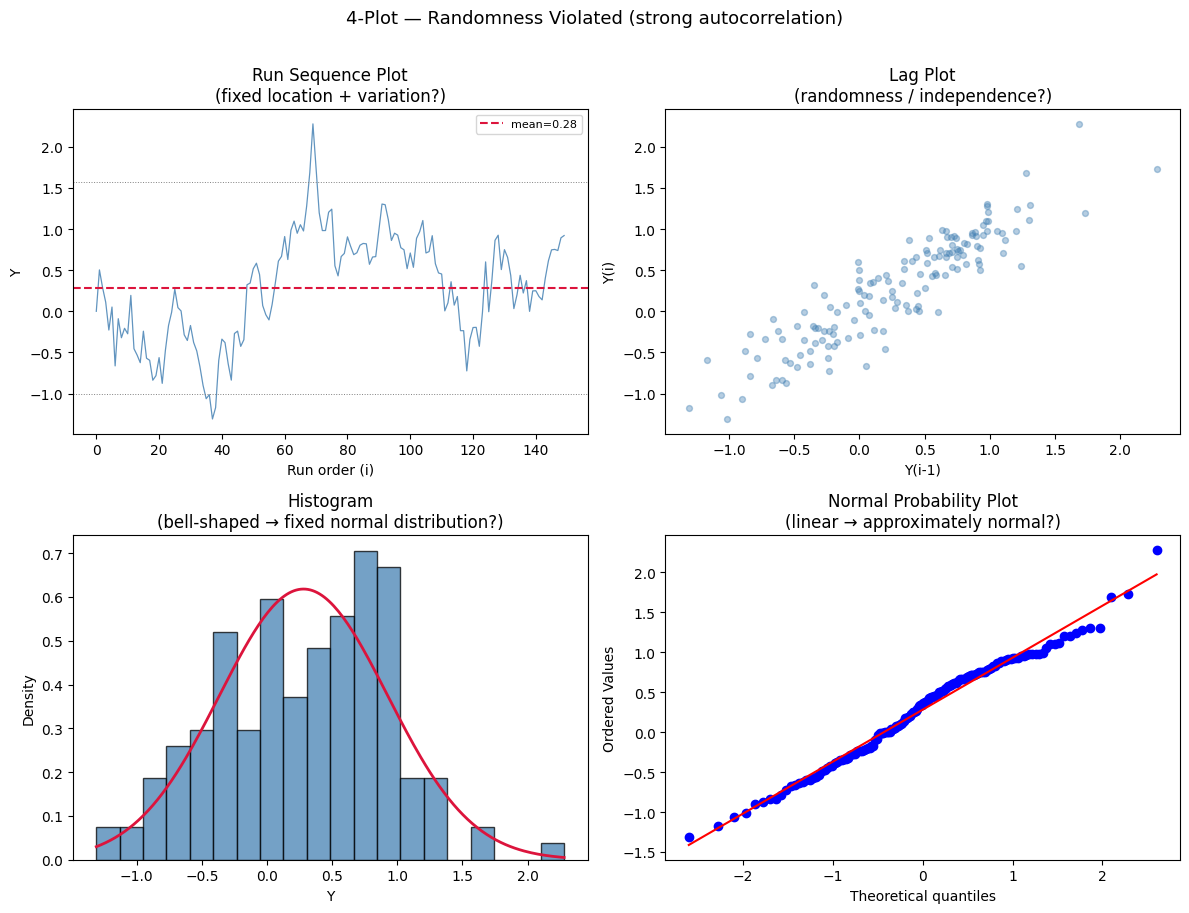

Reading the 4-Plot:
  Run sequence: flat + equi-banded  → fixed location and variation ✓
  Lag plot:     structureless cloud  → randomness ✓  |  diagonal band → violated ✗
  Histogram:    bell-shaped          → distribution approximately normal ✓
  Q-Q plot:     points on diagonal   → distribution approximately normal ✓


In [11]:
# Demo 2: autocorrelated data — randomness assumption violated
np.random.seed(1)
y_bad = np.zeros(150)
y_bad[0] = 0
for i in range(1, 150):
    y_bad[i] = 0.95 * y_bad[i-1] + np.random.normal(0, 0.31)

four_plot(y_bad, title='4-Plot — Randomness Violated (strong autocorrelation)')

print("Reading the 4-Plot:")
print("  Run sequence: flat + equi-banded  → fixed location and variation ✓")
print("  Lag plot:     structureless cloud  → randomness ✓  |  diagonal band → violated ✗")
print("  Histogram:    bell-shaped          → distribution approximately normal ✓")
print("  Q-Q plot:     points on diagonal   → distribution approximately normal ✓")